In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Selection of Reference texts

Nous allons d'abord travailler sur la France de 2010 à 2020 en sélectionnant des manifestes de partis Right-Center-Left. Cela sera choisi sur la base de l'**indice RILE** développé dans le manifesto.

In [6]:
import pandas as pd 
from wordscores import wordscores as ws

In [7]:
manifestoData = pd.read_csv("../data/processed/manifesto_data.csv", low_memory=False)

rileData = manifestoData[["countryname", "partyname", "date", "rile"]].copy()
rileData["date"] = pd.to_datetime(rileData["date"], format="%Y%m", errors="coerce").dt.year

In [8]:
filled_rile_data = ws.fill_rile_by_party_country(rileData, method="mean")

RILE missing-value treatment
----------------------------
Method: party-country mean
Missing RILE values before imputation: 99
Values imputed: 67
Rows dropped: 32
Missing RILE values after cleaning: 0


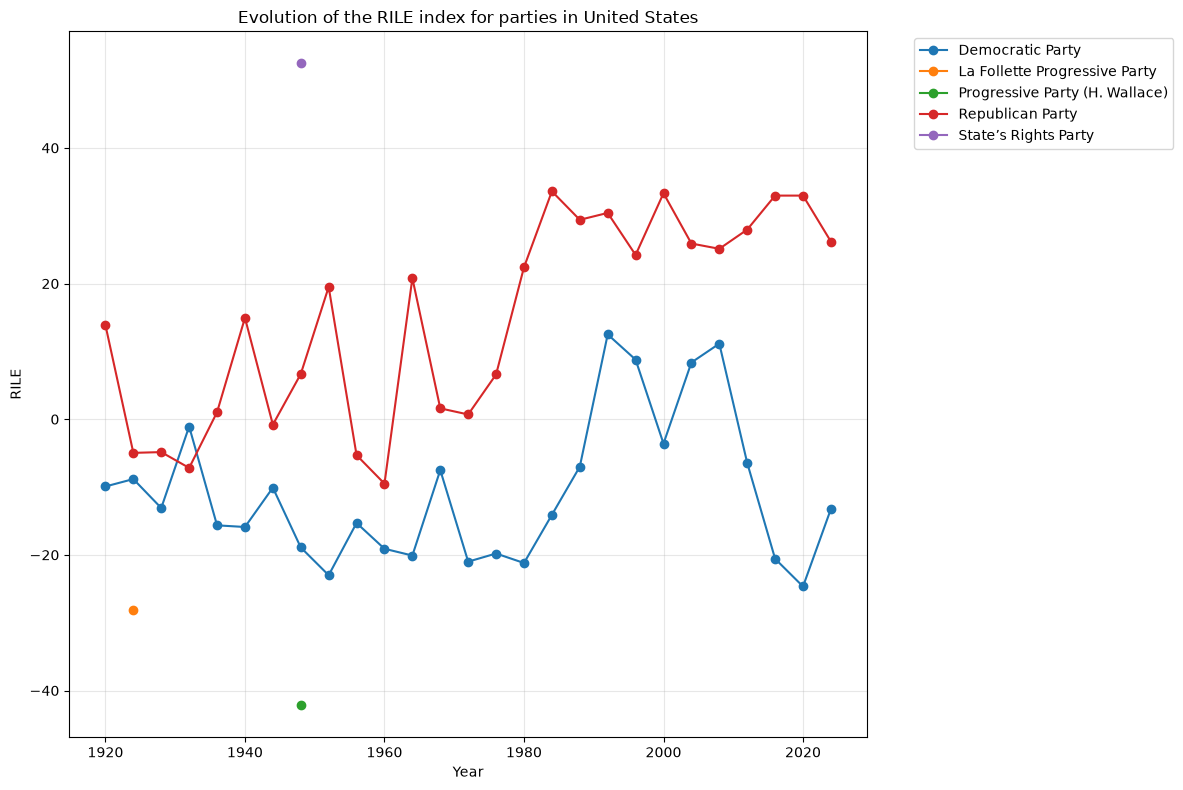

In [9]:
usa_rile_values = ws.plot_country_parties(filled_rile_data, "United States")

# Wordscore Method

## Testing the methods for USA



In [10]:
reference_years_list = list(range(1960, 2003, 4))
virgin_years_list = list(range(2004, 2026, 4))

### A priori scores

useful_usa_rile_values = usa_rile_values[
    usa_rile_values["partyname"].isin(["Democratic Party", "Republican Party"])
    & usa_rile_values["date"].isin(reference_years_list)
].copy()

useful_usa_rile_values = useful_usa_rile_values.sort_values(["partyname","date"])

# A priori scores for the reference texts based on their RILE values
a_priori_scores = useful_usa_rile_values["rile"].values 

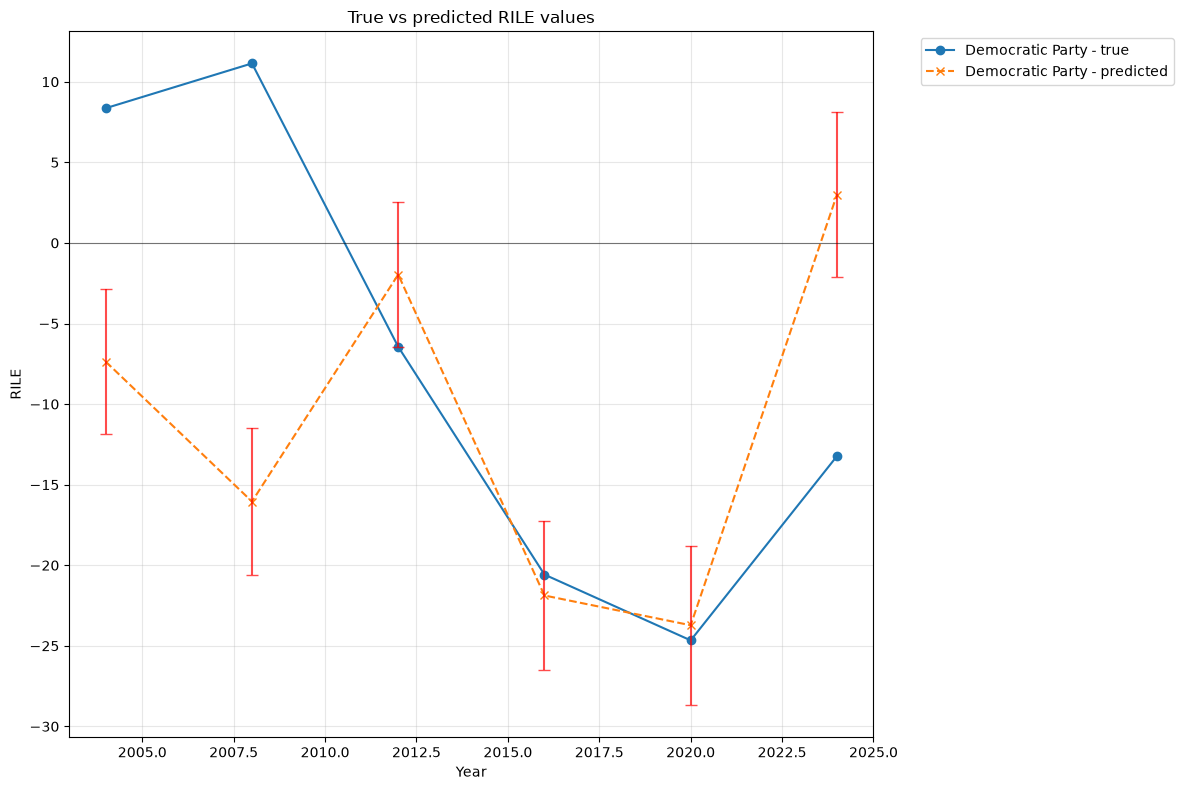

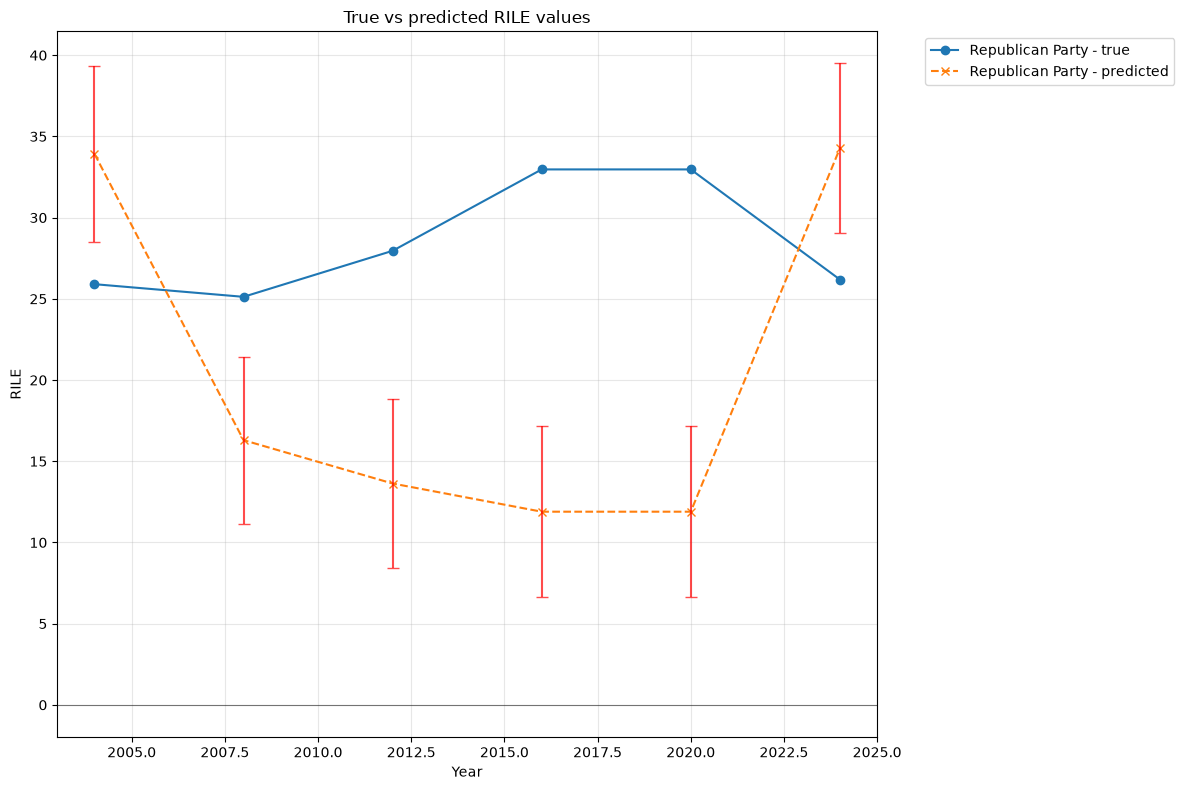

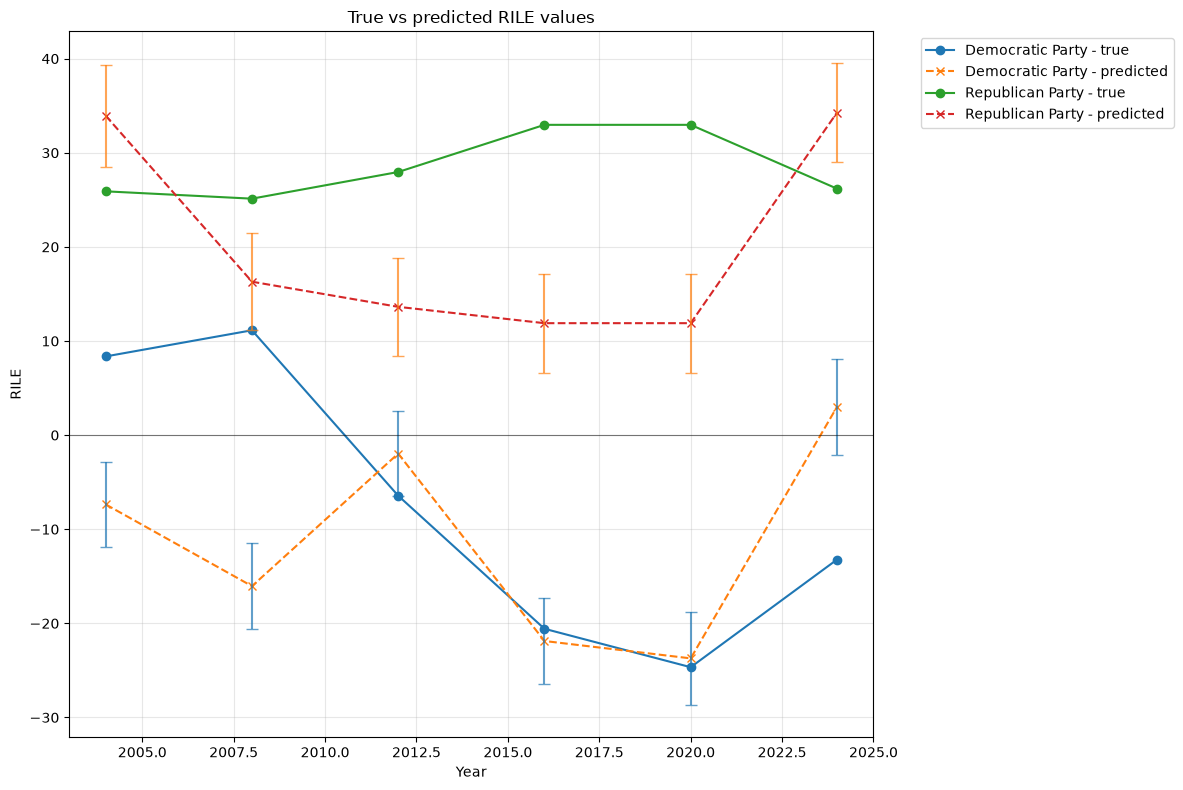

In [12]:
results = ws.run_wordscores_usa(
    manifesto_dir="../data/raw/manifestos/usa",
    a_priori_scores=a_priori_scores,
    reference_years_list=reference_years_list,
    virgin_years_list=virgin_years_list,
    verbose=False
)

deviations = ws.plot_true_vs_predicted_rile(
    virgin_scores=results["virgin_scores"],
    rile_values=usa_rile_values,
    score_col="Score",
    display_ci=True,
    party_names=["Democratic Party"]
)

ws.plot_true_vs_predicted_rile(
    virgin_scores=results["virgin_scores"],
    rile_values=usa_rile_values,
    score_col="Score",
    display_ci=True,
    party_names=["Republican Party"]
)

ws.plot_true_vs_predicted_rile(
    virgin_scores=results["virgin_scores"],
    rile_values=usa_rile_values,
    score_col="Score",
    display_ci=True,
    party_names=["Democratic Party", "Republican Party"]
)

# Iterative Wordscore: Updating the reference texts through years

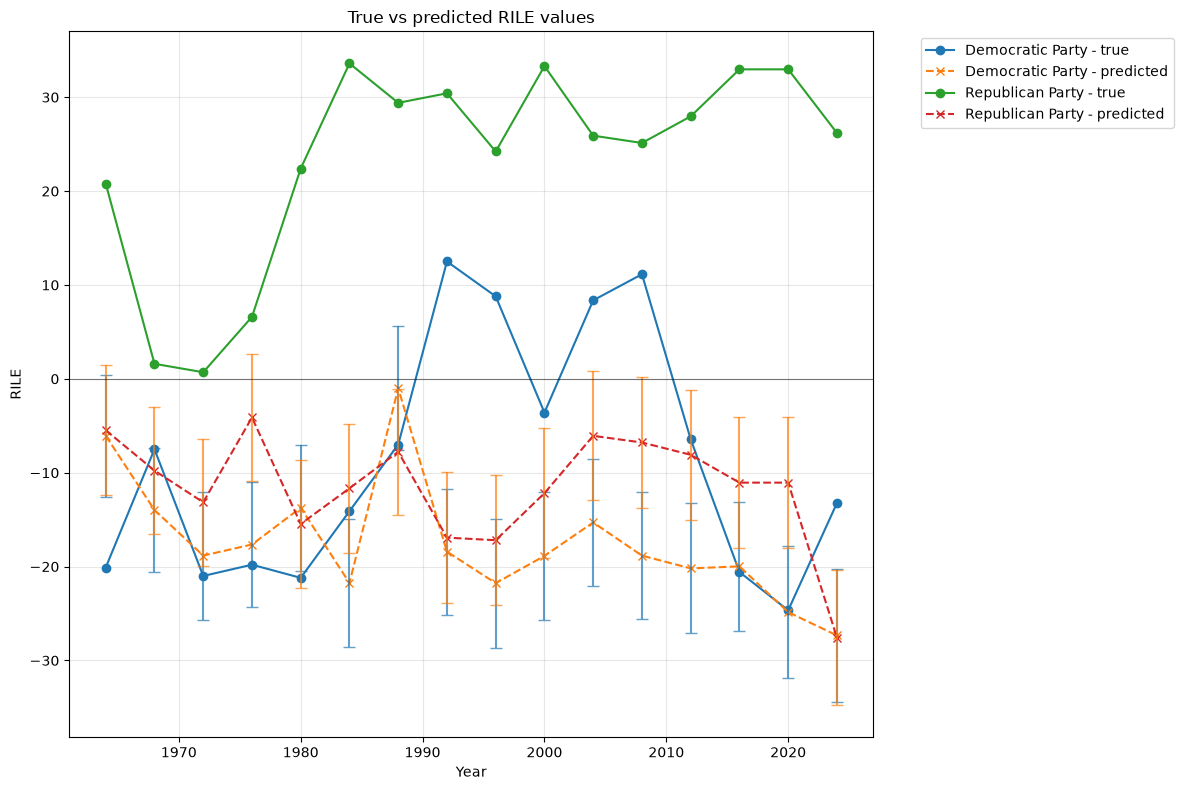

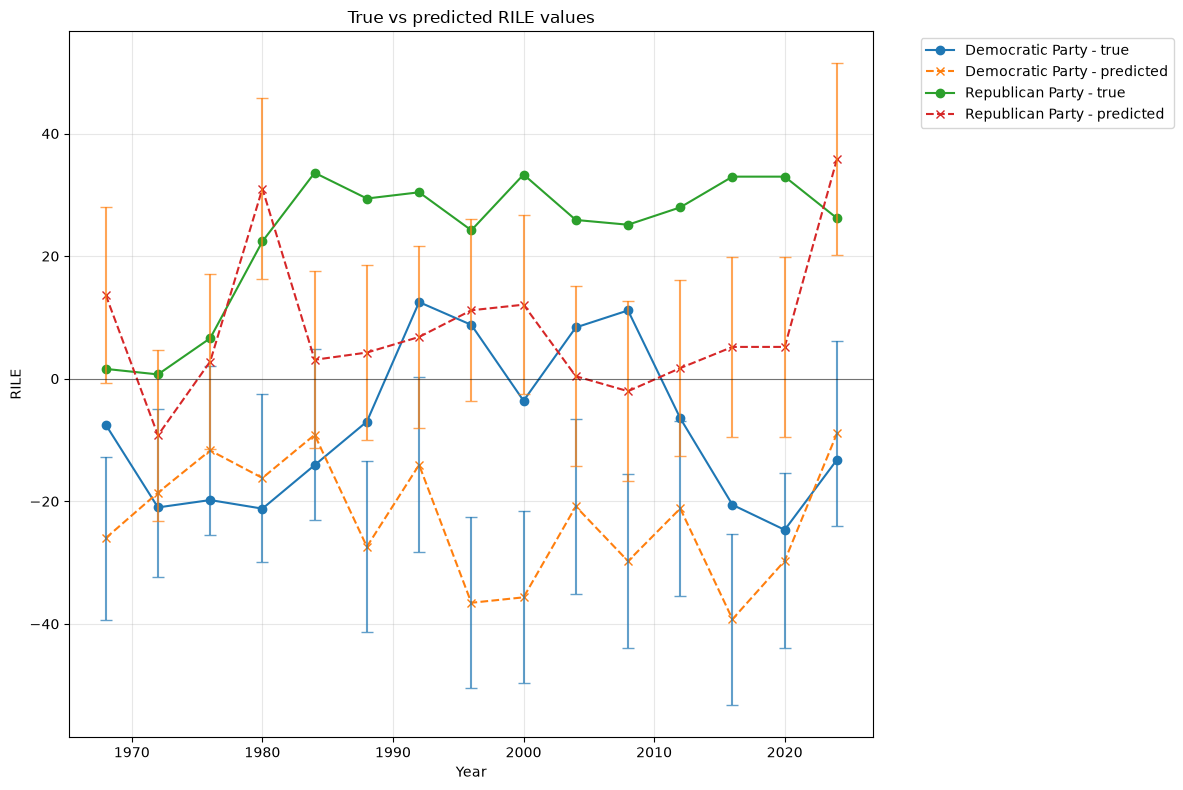

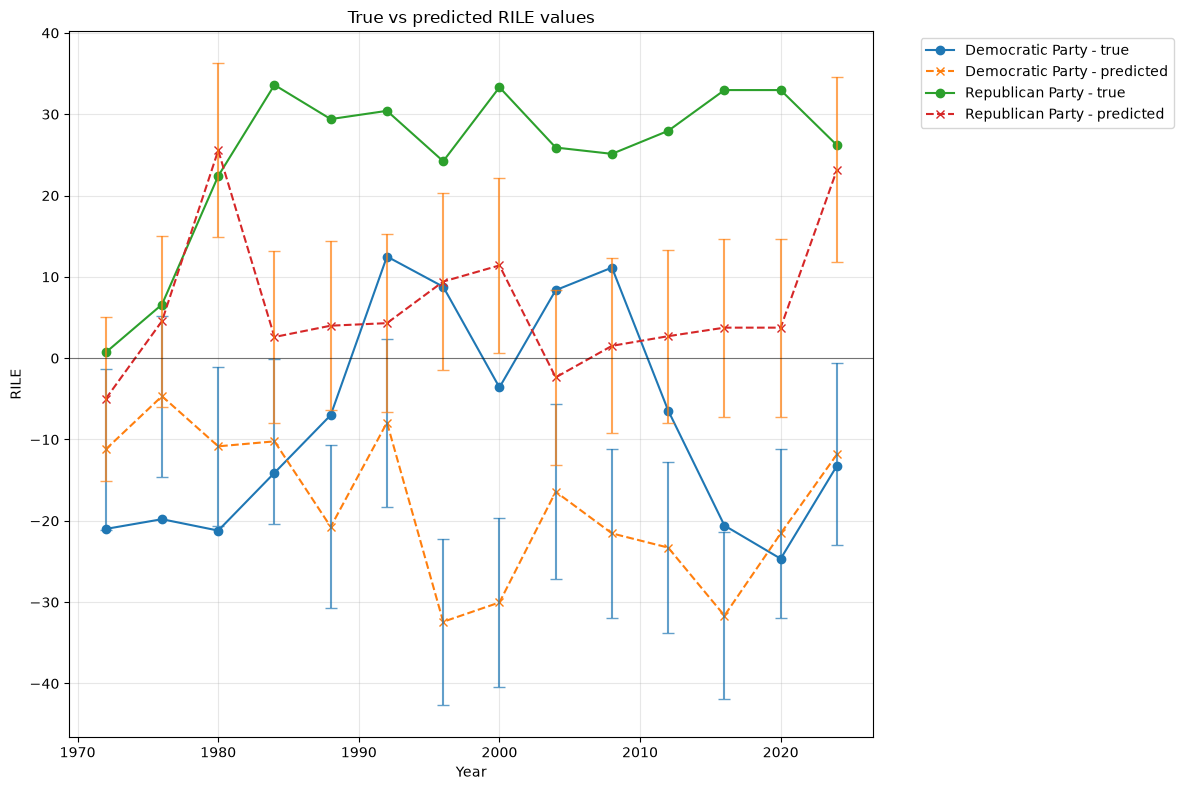

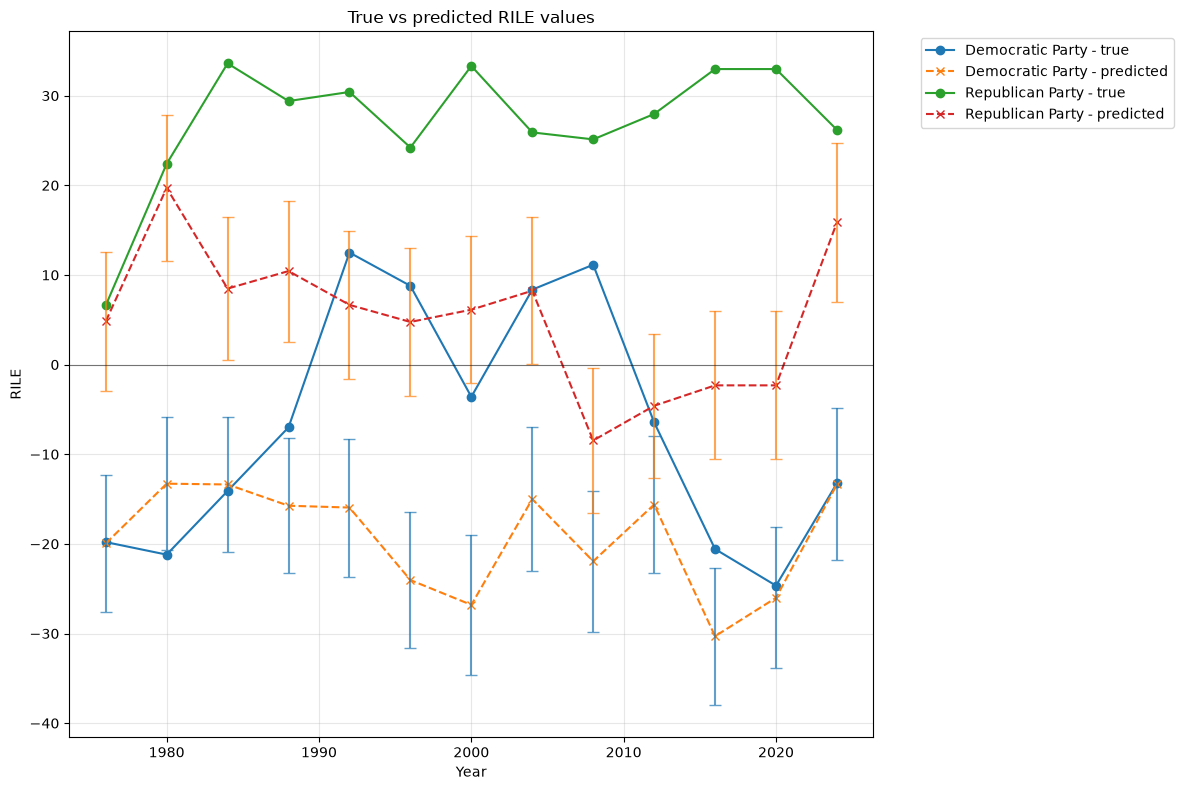

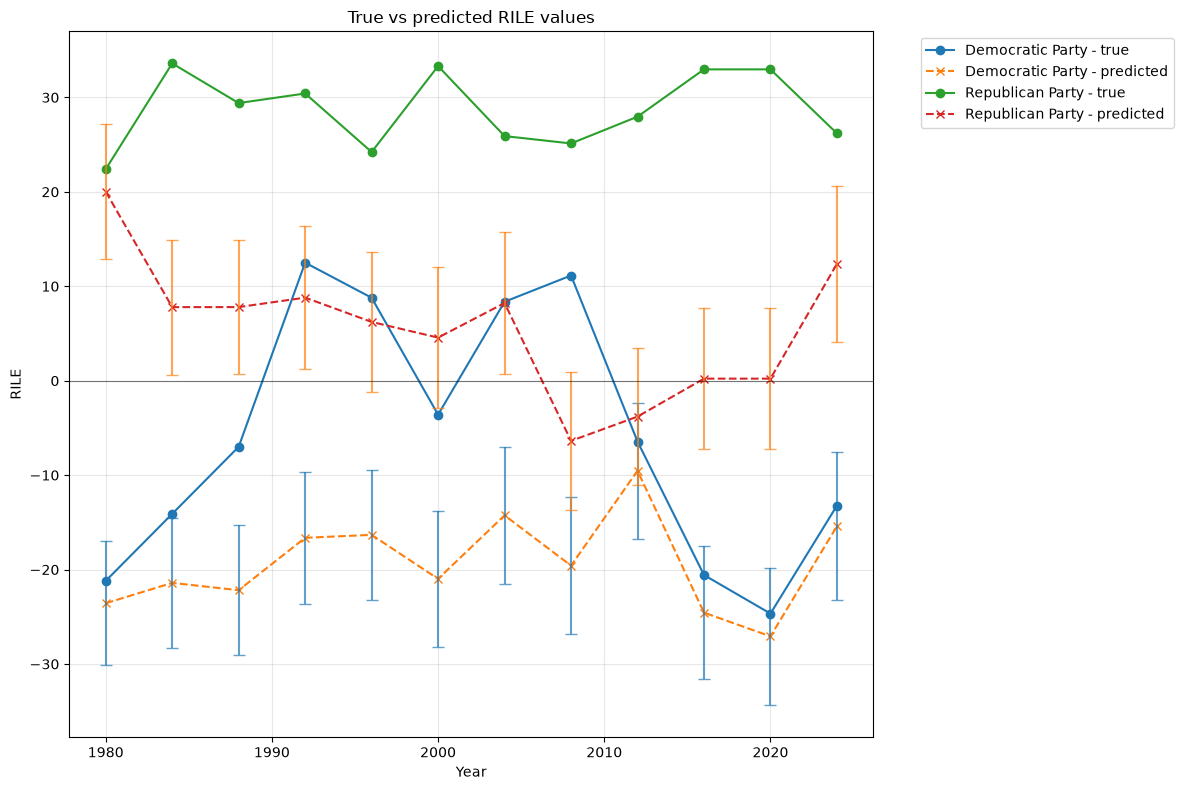

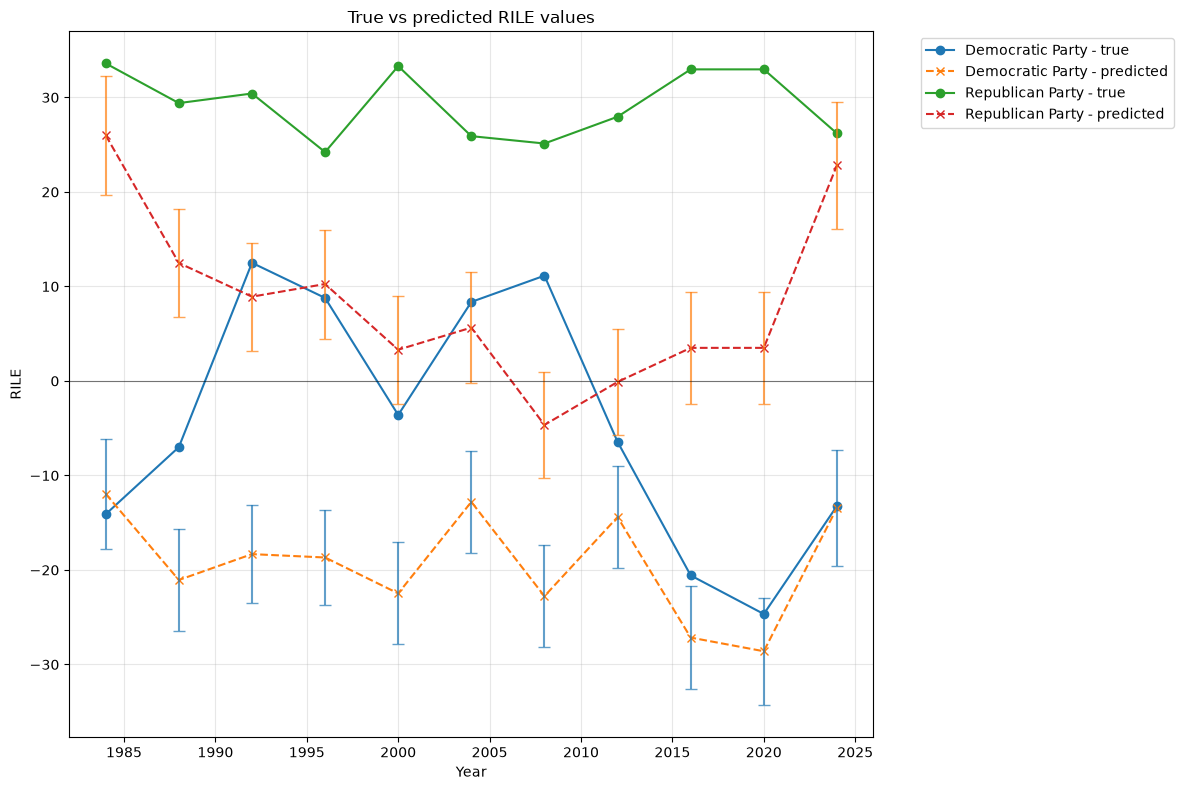

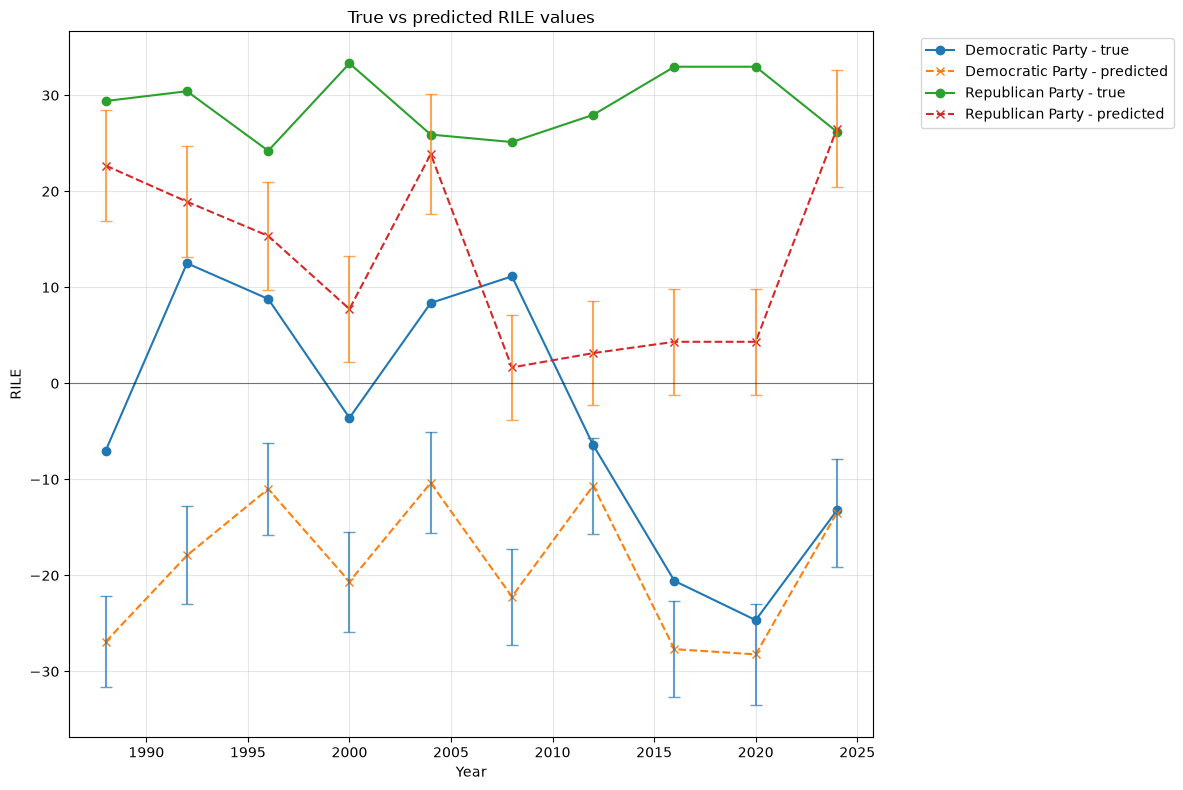

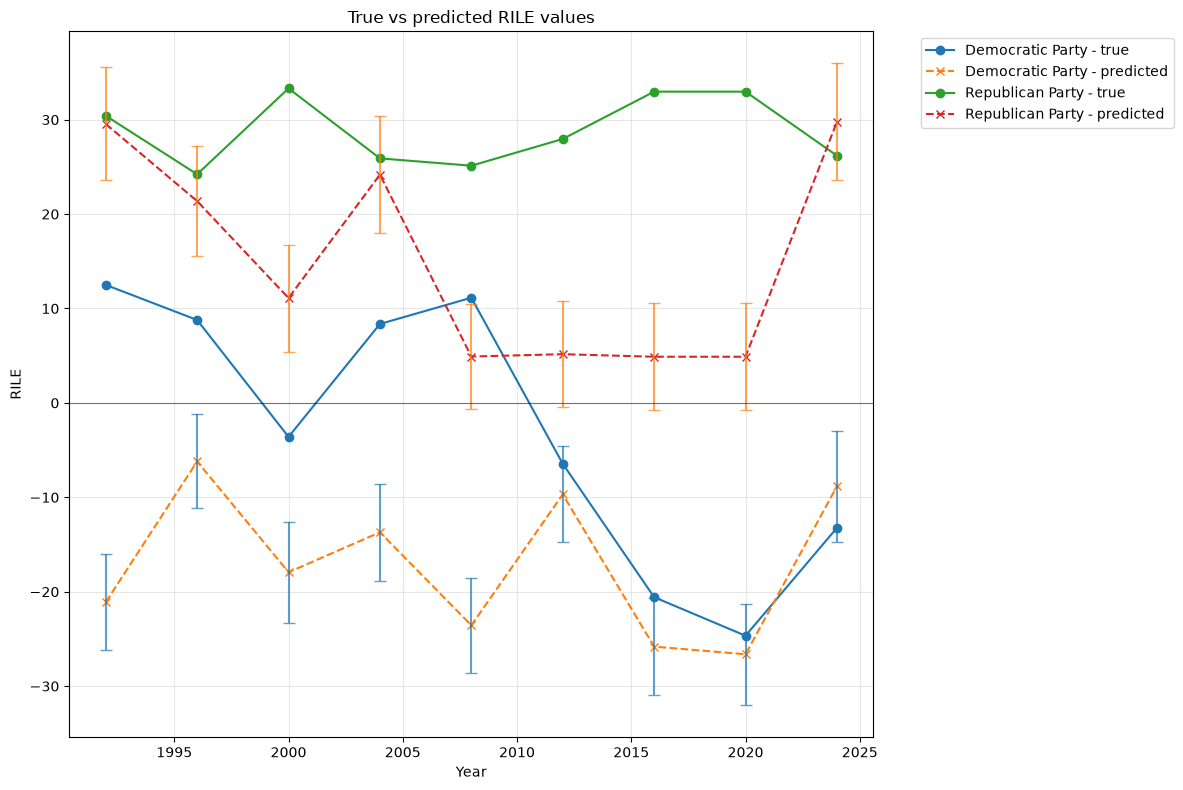

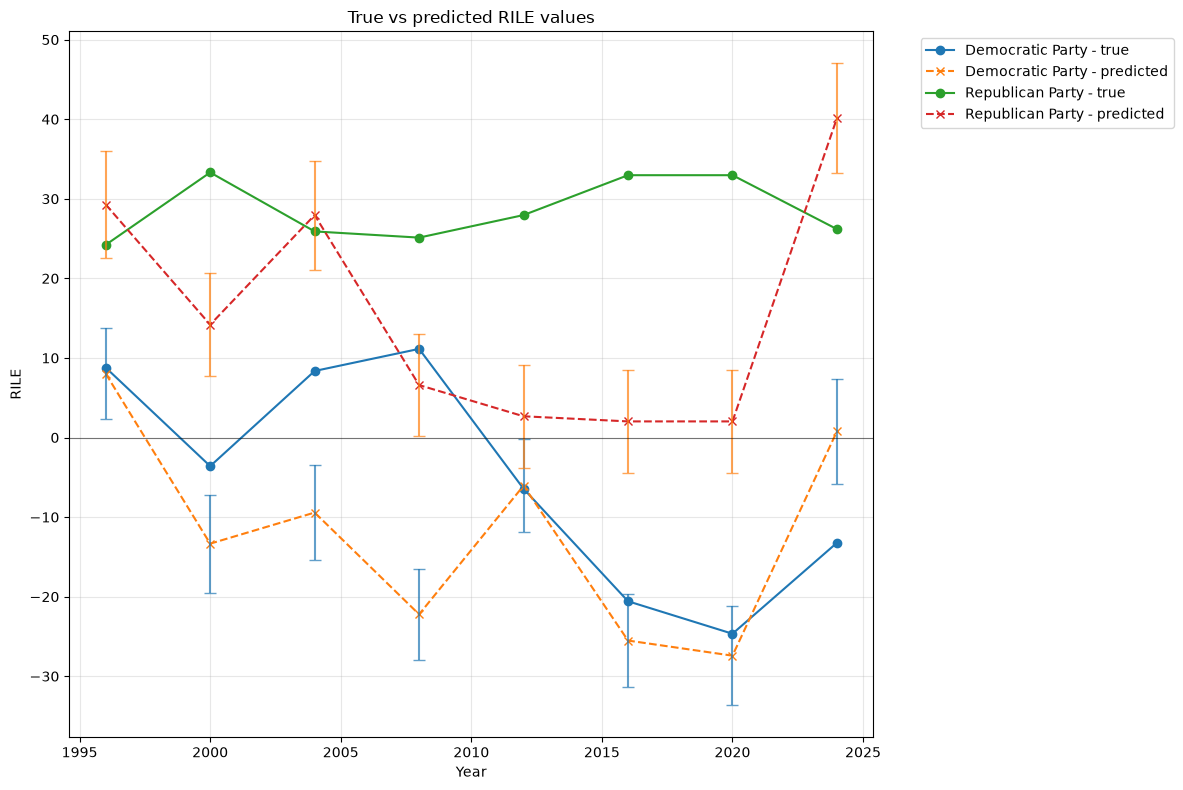

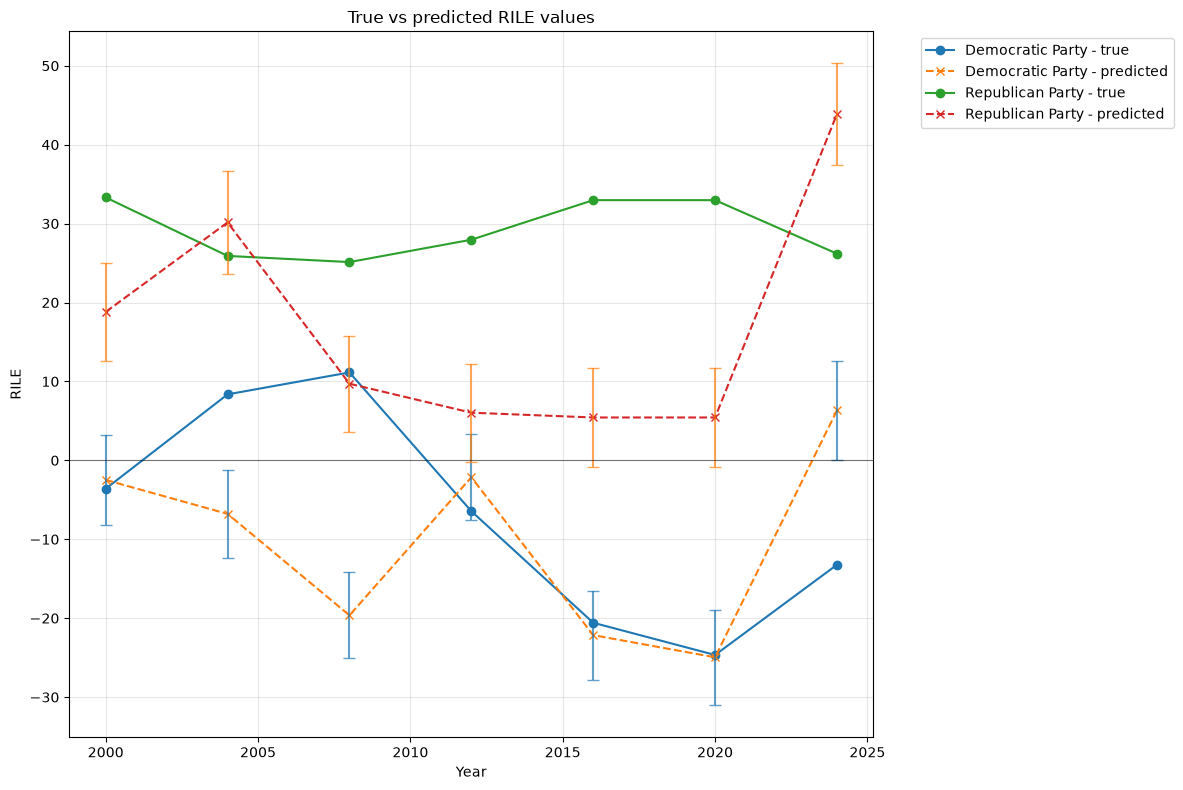

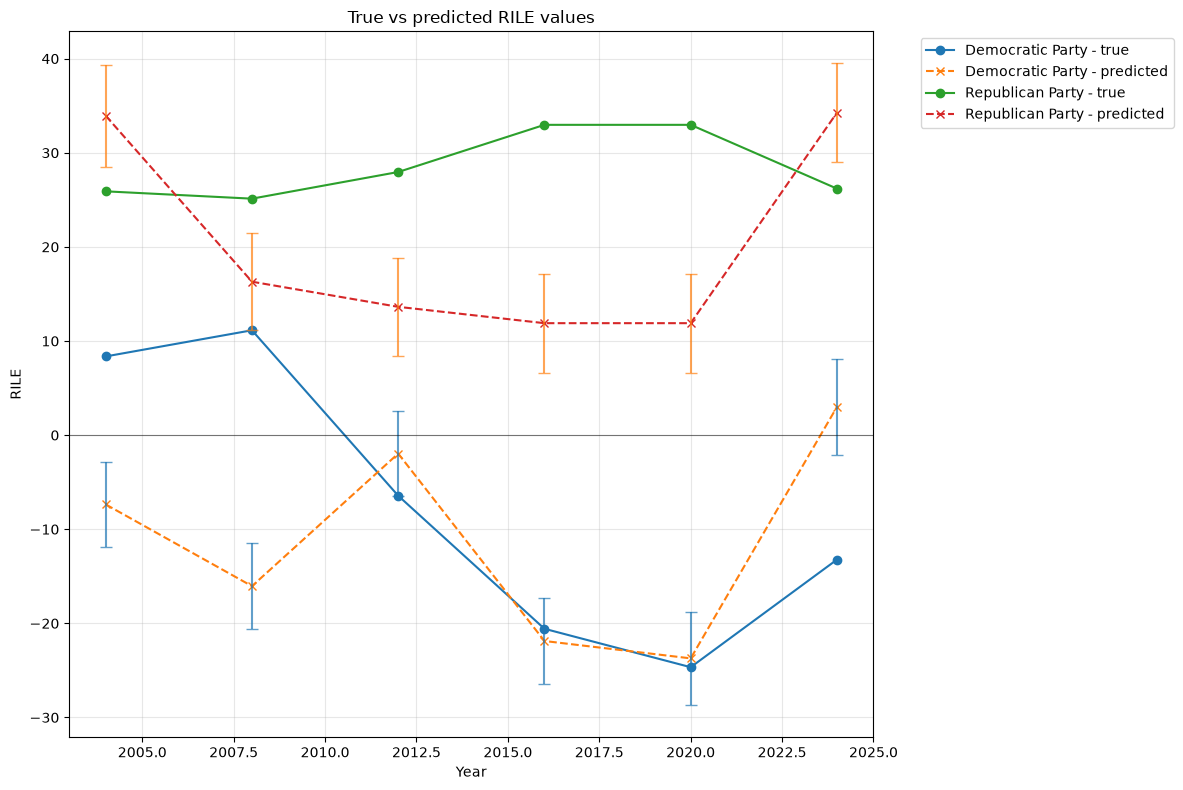

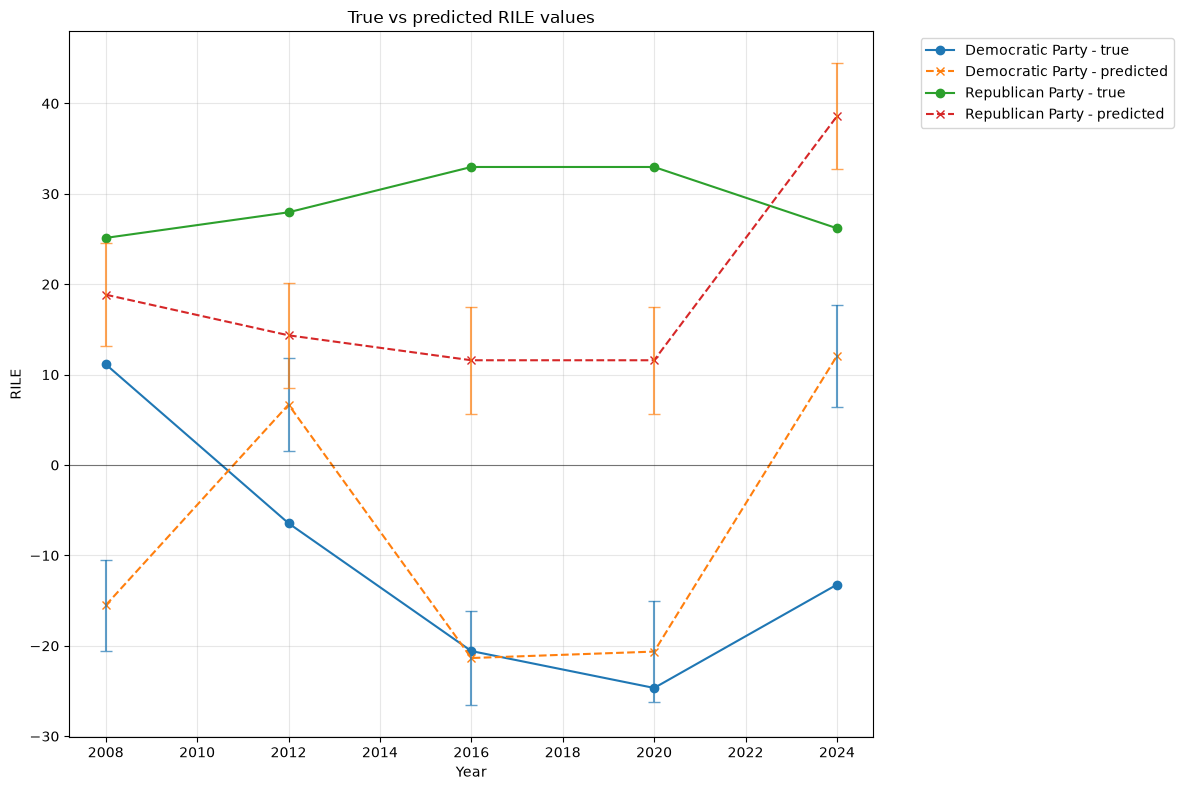

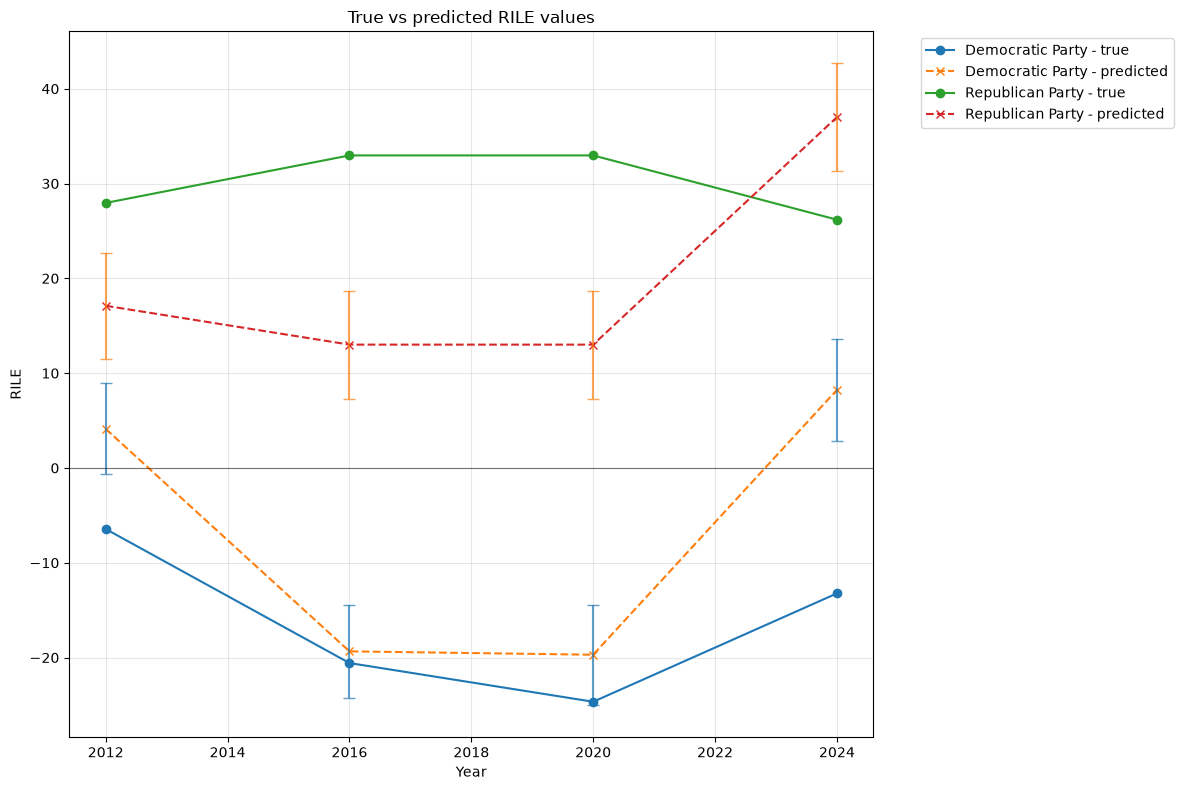

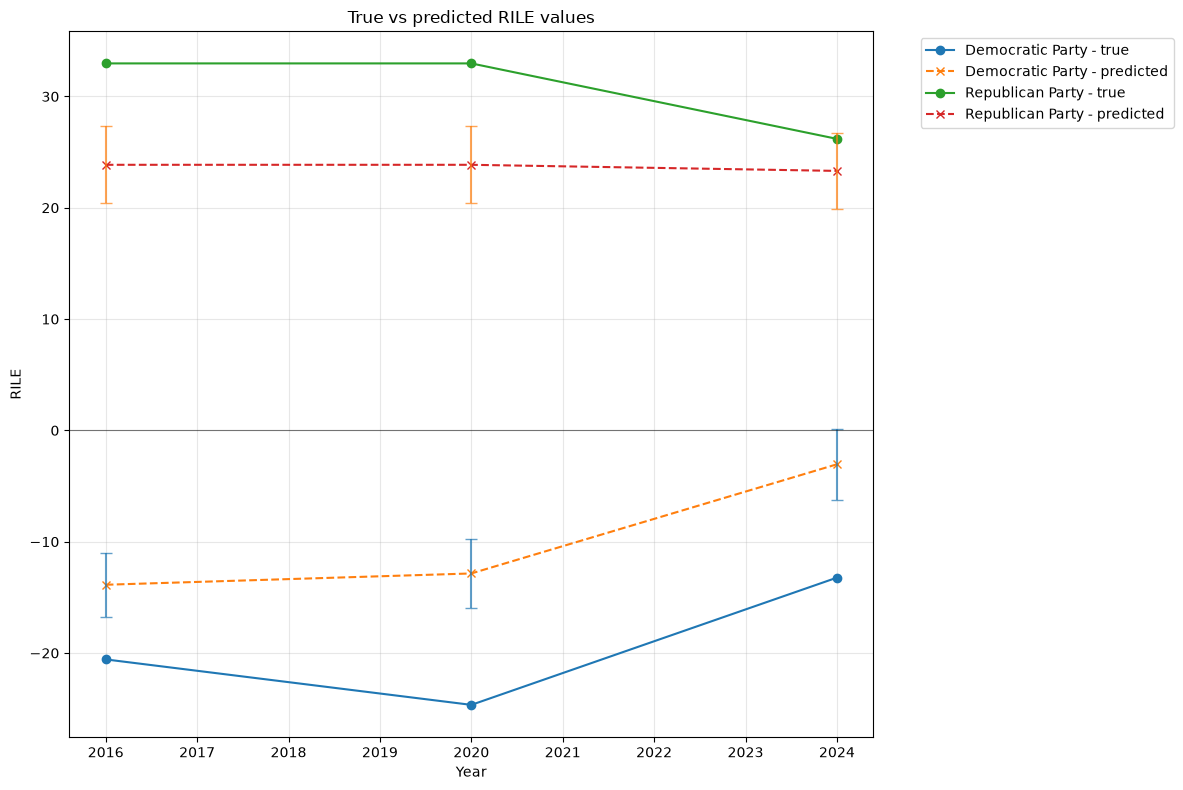

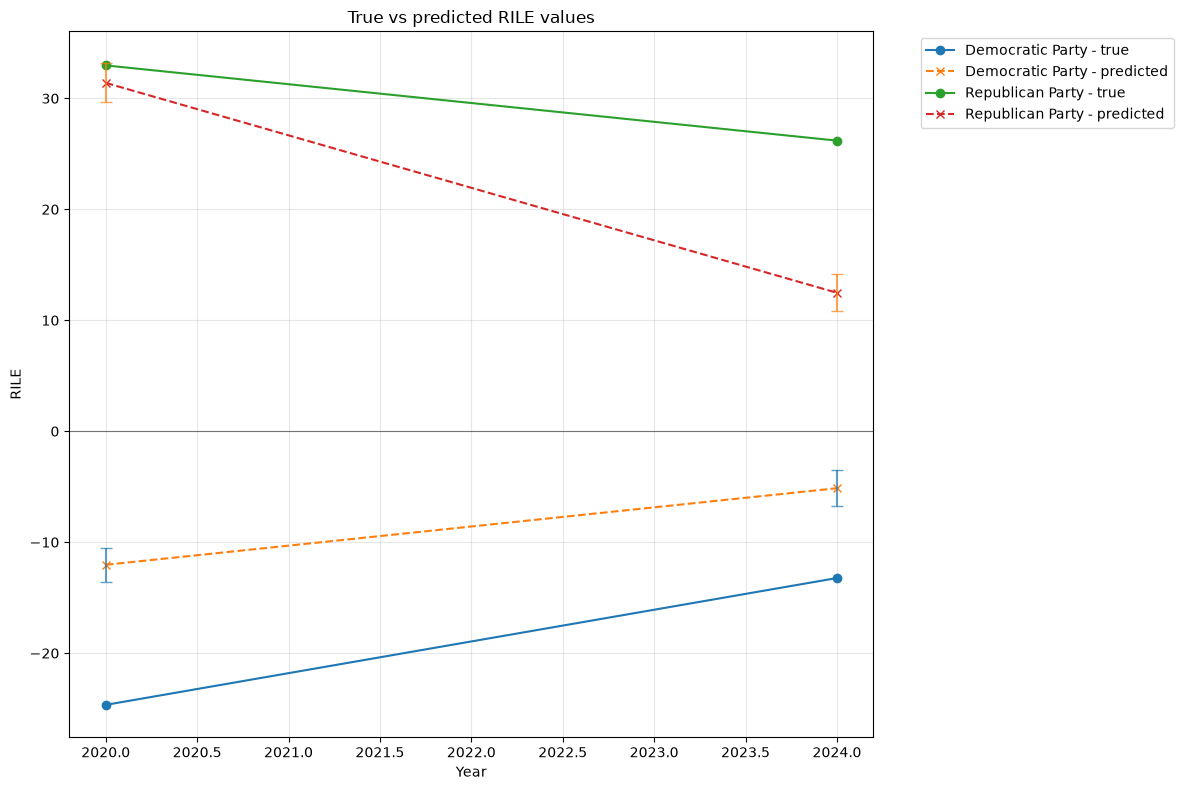

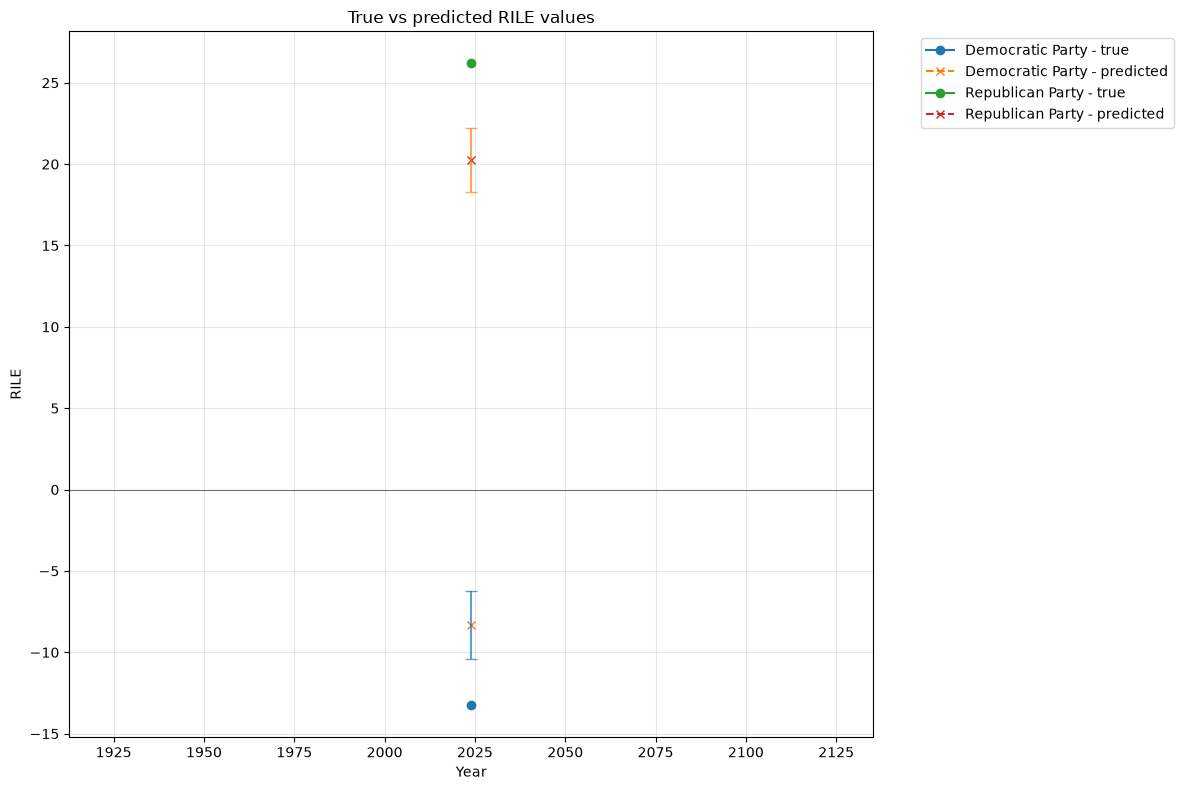

In [13]:
usa_years_list = list(range(1960, 2026, 4))
default_min_reference_years=1

iterative_results = ws.run_iterative_wordscores(
    years_list=usa_years_list,
    rile_values=usa_rile_values,
    manifesto_dir="../data/raw/manifestos/usa",
    parties=["Democratic Party", "Republican Party"],
    min_reference_years=default_min_reference_years
)

for i in range(default_min_reference_years, len(usa_years_list)):

    ws.plot_true_vs_predicted_rile(
    virgin_scores=iterative_results[i],
    rile_values=usa_rile_values,
    score_col="Score",
    display_ci=True,
    party_names=None
    )